# Futures/Spot HBT Step-by-Step Runner

The notebook is intentionally thin. Configuration, pipeline stages, report tables, and plotting live in separate Python scripts in this folder. Both this notebook and `run_full_backtest.py` save CSV reports and PNG figures.

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
TEST_ROOT = CURRENT_DIR if (CURRENT_DIR / 'backtest_config.py').exists() else CURRENT_DIR / 'future_spot' / 'test'
if not TEST_ROOT.exists():
    raise FileNotFoundError('Open this notebook from future_spot/test or the repository root')
PROJECT_ROOT = TEST_ROOT.parent
WORKSPACE_ROOT = PROJECT_ROOT.parent
for path in (TEST_ROOT, PROJECT_ROOT, WORKSPACE_ROOT, PROJECT_ROOT / 'scripts'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from IPython.display import Image, display
from backtest_config import default_notebook_args
from backtest_pipeline import run_backtest_pipeline
from report_tables import build_report_tables
from report_plots import save_report_plots

## 1. Parameters

In [2]:
args = default_notebook_args(
    start_date='2026-07-01',
    end_date='2026-07-31',
    order_latency_ms=10.0,
    continue_on_error=True,
    response_latency_ms=10.0,
    feed_latency_offset_ms=10.0,
    post_first_feed_wait='spot',
    post_first_feed_timeout_ms=5000.0,
    rebuild_hbt_results=True,
)
args.output_dir

PosixPath('/home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260701_20260731_latency_10ms')

## 2. Full Backtest and Core CSV Outputs

In [3]:
artifacts = run_backtest_pipeline(args)
display(artifacts.frame('summary').head(20))
display(artifacts.frame('entry_exit_index').head(20))

row_indexes for symbol=2324: {'history.parquet': (8484924, 67575)}
input_rows=67244
converted_rows=67244
skipped_symbol_rows=0
skipped_status_rows=0
skipped_time_rows=0
raw_events=811532
output_events=811532
depth_events=804876
trade_events=6656
opening_jump_qty=0.0
first_exch_ts=1782867610203549000
last_exch_ts=1782883499990710000
min_feed_latency=0
max_feed_latency=0
qa_rows_checked=1000
best_bid_mismatches=0
best_ask_mismatches=0
trade_qty_mismatches=0
load_seconds=1.850607
event_build_seconds=0.320450
normalize_seconds=0.051350
write_seconds=0.464155
output=/home/zoufuc/hftbacktest/data/tw_stock_events/2324_20260701_090000_132500.npz
input_rows=28333
converted_rows=28333
skipped_symbol_rows=0
skipped_status_rows=0
skipped_time_rows=0
raw_events=340277
output_events=340277
depth_events=339996
trade_events=281
opening_jump_qty=0.0
first_exch_ts=1782867601229000000
last_exch_ts=1782883498236000000
min_feed_latency=0
max_feed_latency=0
qa_rows_checked=1000
best_bid_mismatches=0
best_as

,trade_date,run_key,pair_name,spot_symbol,future_symbol,rows,filled_pairs,second_leg_failures,flatten_count,realized_pnl,...,step_ns,second_leg_delay_ns,post_first_feed_wait,post_first_feed_timeout_ns,post_first_feed_poll_ns,spot_order_latency_ns,future_order_latency_ns,strategy_engine,scan_calls,python_decisions
0,2026-07-01,2026-07-01::2324_CGFG6,2324_CGFG6,2324,CGFG6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
1,2026-07-01,2026-07-01::2409_CHFG6,2409_CHFG6,2409,CHFG6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,1,0
2,2026-07-01,2026-07-01::1605_CSFG6,1605_CSFG6,1605,CSFG6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,1,0
3,2026-07-01,2026-07-01::2408_CYFG6,2408_CYFG6,2408,CYFG6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
4,2026-07-01,2026-07-01::2610_DBFG6,2610_DBFG6,2610,DBFG6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,1,0
5,2026-07-01,2026-07-01::1326_DGFG6,1326_DGFG6,1326,DGFG6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,1,0
6,2026-07-01,2026-07-01::2337_DIFG6,2337_DIFG6,2337,DIFG6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
7,2026-07-01,2026-07-01::3481_DQFG6,3481_DQFG6,3481,DQFG6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,1,0
8,2026-07-01,2026-07-01::2353_DSFG6,2353_DSFG6,2353,DSFG6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
9,2026-07-01,2026-07-01::3231_DXFG6,3231_DXFG6,3231,DXFG6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,1,0


,trade_date,run_key,pair_name,rows,entry_signal_rows,entry_execution_rows,exit_execution_rows
0,2026-07-01,2026-07-01::2324_CGFG6,2324_CGFG6,0,0,0,0
1,2026-07-01,2026-07-01::2409_CHFG6,2409_CHFG6,0,0,0,0
2,2026-07-01,2026-07-01::1605_CSFG6,1605_CSFG6,0,0,0,0
3,2026-07-01,2026-07-01::2408_CYFG6,2408_CYFG6,0,0,0,0
4,2026-07-01,2026-07-01::2610_DBFG6,2610_DBFG6,0,0,0,0
5,2026-07-01,2026-07-01::1326_DGFG6,1326_DGFG6,0,0,0,0
6,2026-07-01,2026-07-01::2337_DIFG6,2337_DIFG6,0,0,0,0
7,2026-07-01,2026-07-01::3481_DQFG6,3481_DQFG6,0,0,0,0
8,2026-07-01,2026-07-01::2353_DSFG6,2353_DSFG6,0,0,0,0
9,2026-07-01,2026-07-01::3231_DXFG6,3231_DXFG6,0,0,0,0


## 3. Analysis CSV Outputs

In [4]:
reports = build_report_tables(artifacts)
display(reports.frame('symbol_profit').head(30))
display(reports.frame('failure_overview'))
display(reports.frame('roi_summary_including_open'))
print(f'Report CSV directory: {reports.output_dir}')

,spot_symbol,trade_days,pair_names,estimated_profit,avg_daily_profit,filled_pairs,second_leg_failures,flatten_count,final_quantity_abs
0,6182,15,2,71468.02,4764.534667,20,0,0,0.0
1,1301,20,2,0.00,0.000000,0,0,0,0.0
2,1312,2,2,0.00,0.000000,0,0,0,0.0
3,1314,11,2,0.00,0.000000,0,0,0,0.0
4,1326,21,2,0.00,0.000000,0,0,0,0.0
5,1605,10,2,0.00,0.000000,0,0,0,0.0
6,1717,4,1,0.00,0.000000,0,0,0,0.0
7,1718,7,2,0.00,0.000000,1,0,0,1.0
8,1802,16,2,0.00,0.000000,0,0,0,0.0
9,1303,14,2,0.00,0.000000,0,0,0,0.0


,pairs_with_summary_failures,failure_trade_rows,market_window_rows,trade_dates,pair_names,flatten_count
0,4,3681,77242,3,3,3680.0


,entry_cash_out,net_stock_cash_stuck,realized_pnl,open_locked_pnl,total_pnl_including_open,total_roi_on_entry_cash_pct,open_roi_on_stuck_cash_pct,open_pairs
0,3.471284e+06,-93557.2869,71468.02,498.1737,71966.1937,0.020732,-0.005325,1.0


Report CSV directory: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260701_20260731_latency_10ms/reports


## 4. Saved PNG Outputs

performance_overview: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260701_20260731_latency_10ms/figures/performance_overview.png


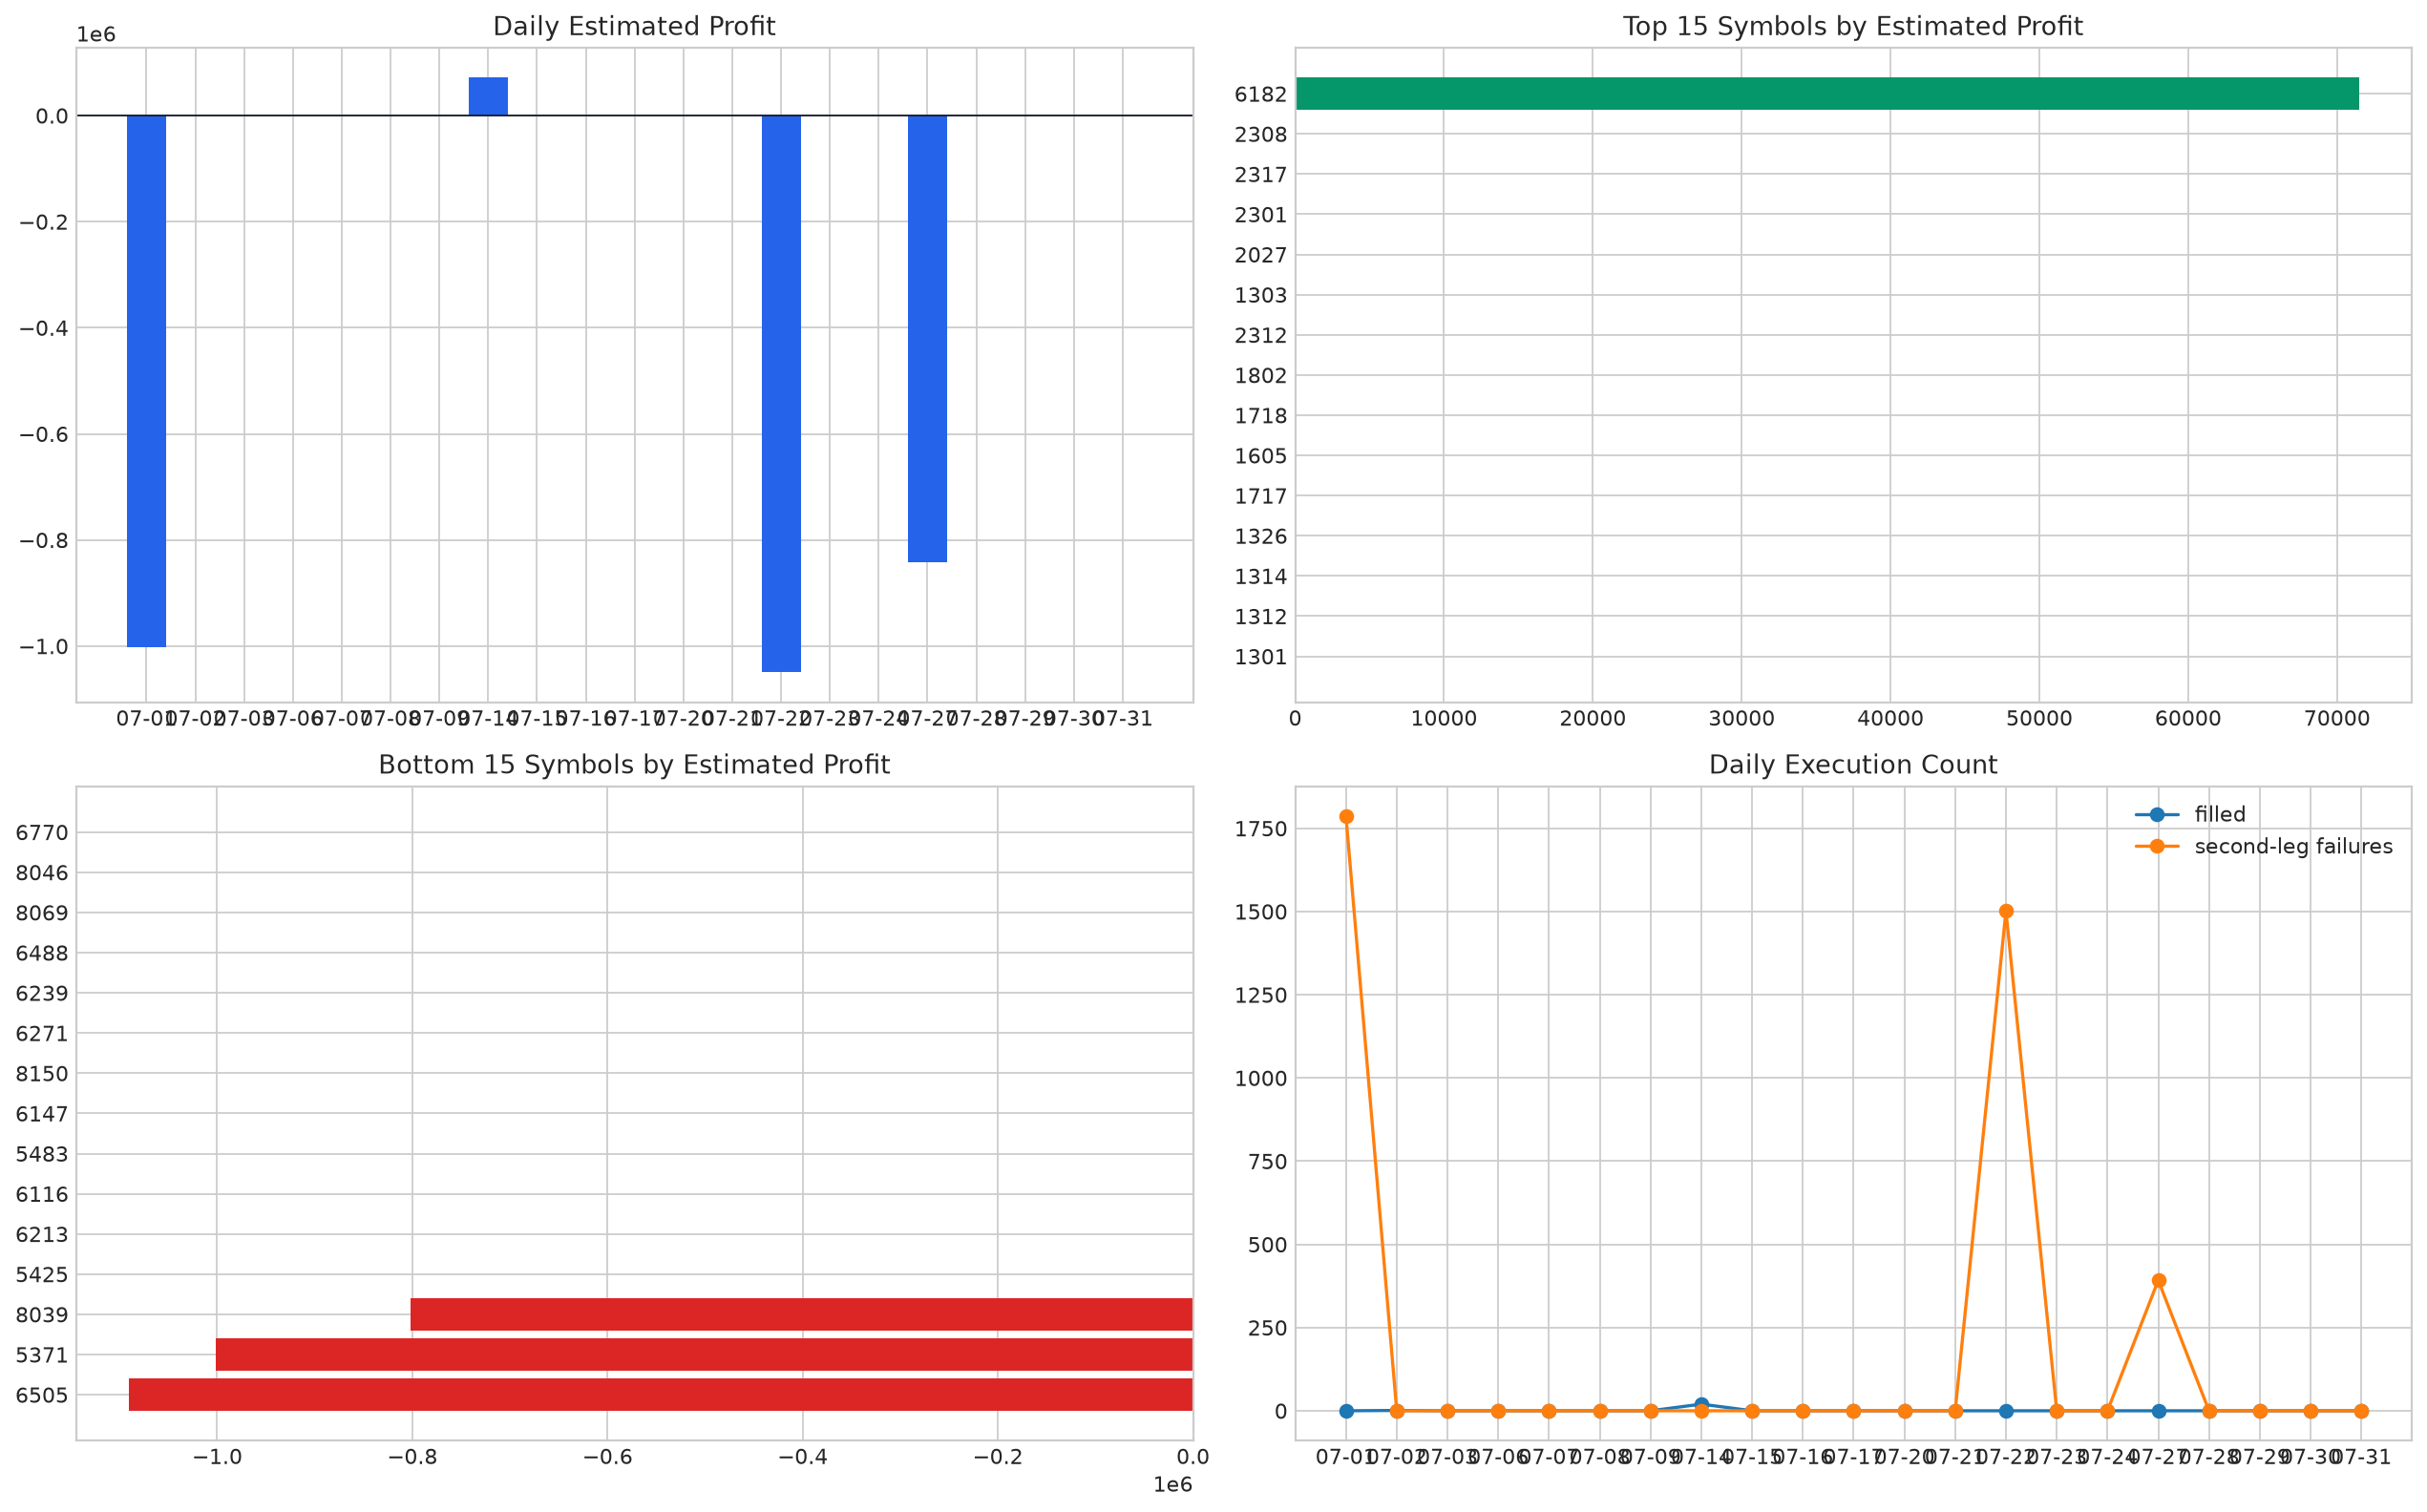

pair_profit_scatter: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260701_20260731_latency_10ms/figures/pair_profit_scatter.png


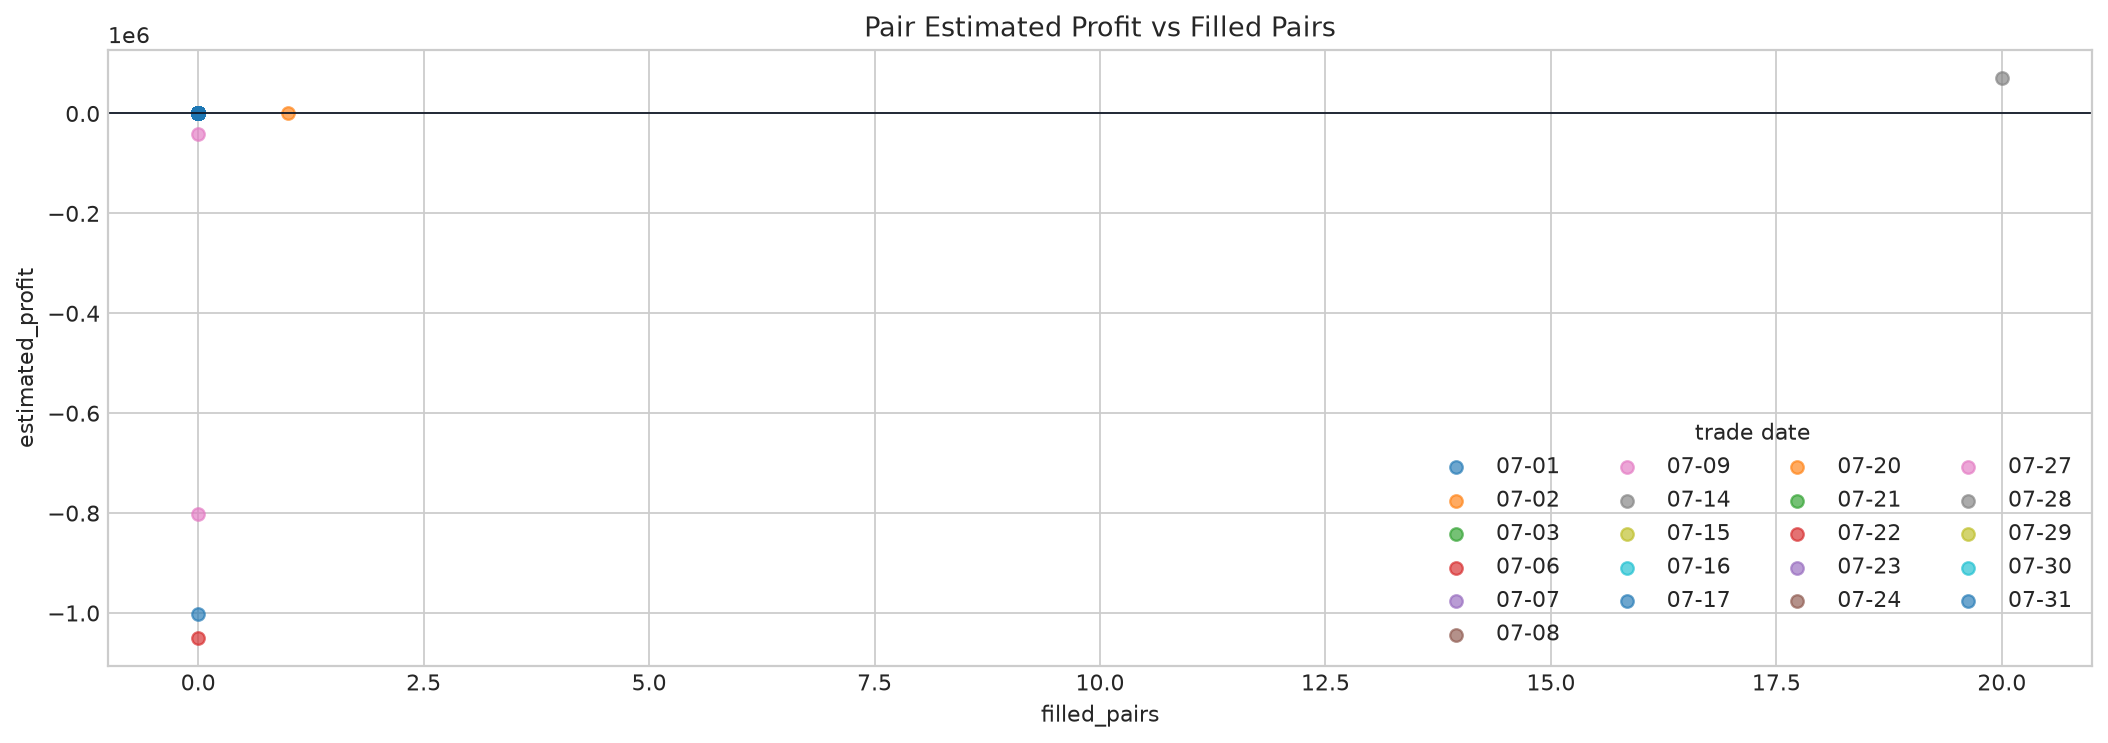

stuck_cash: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260701_20260731_latency_10ms/figures/stuck_cash.png


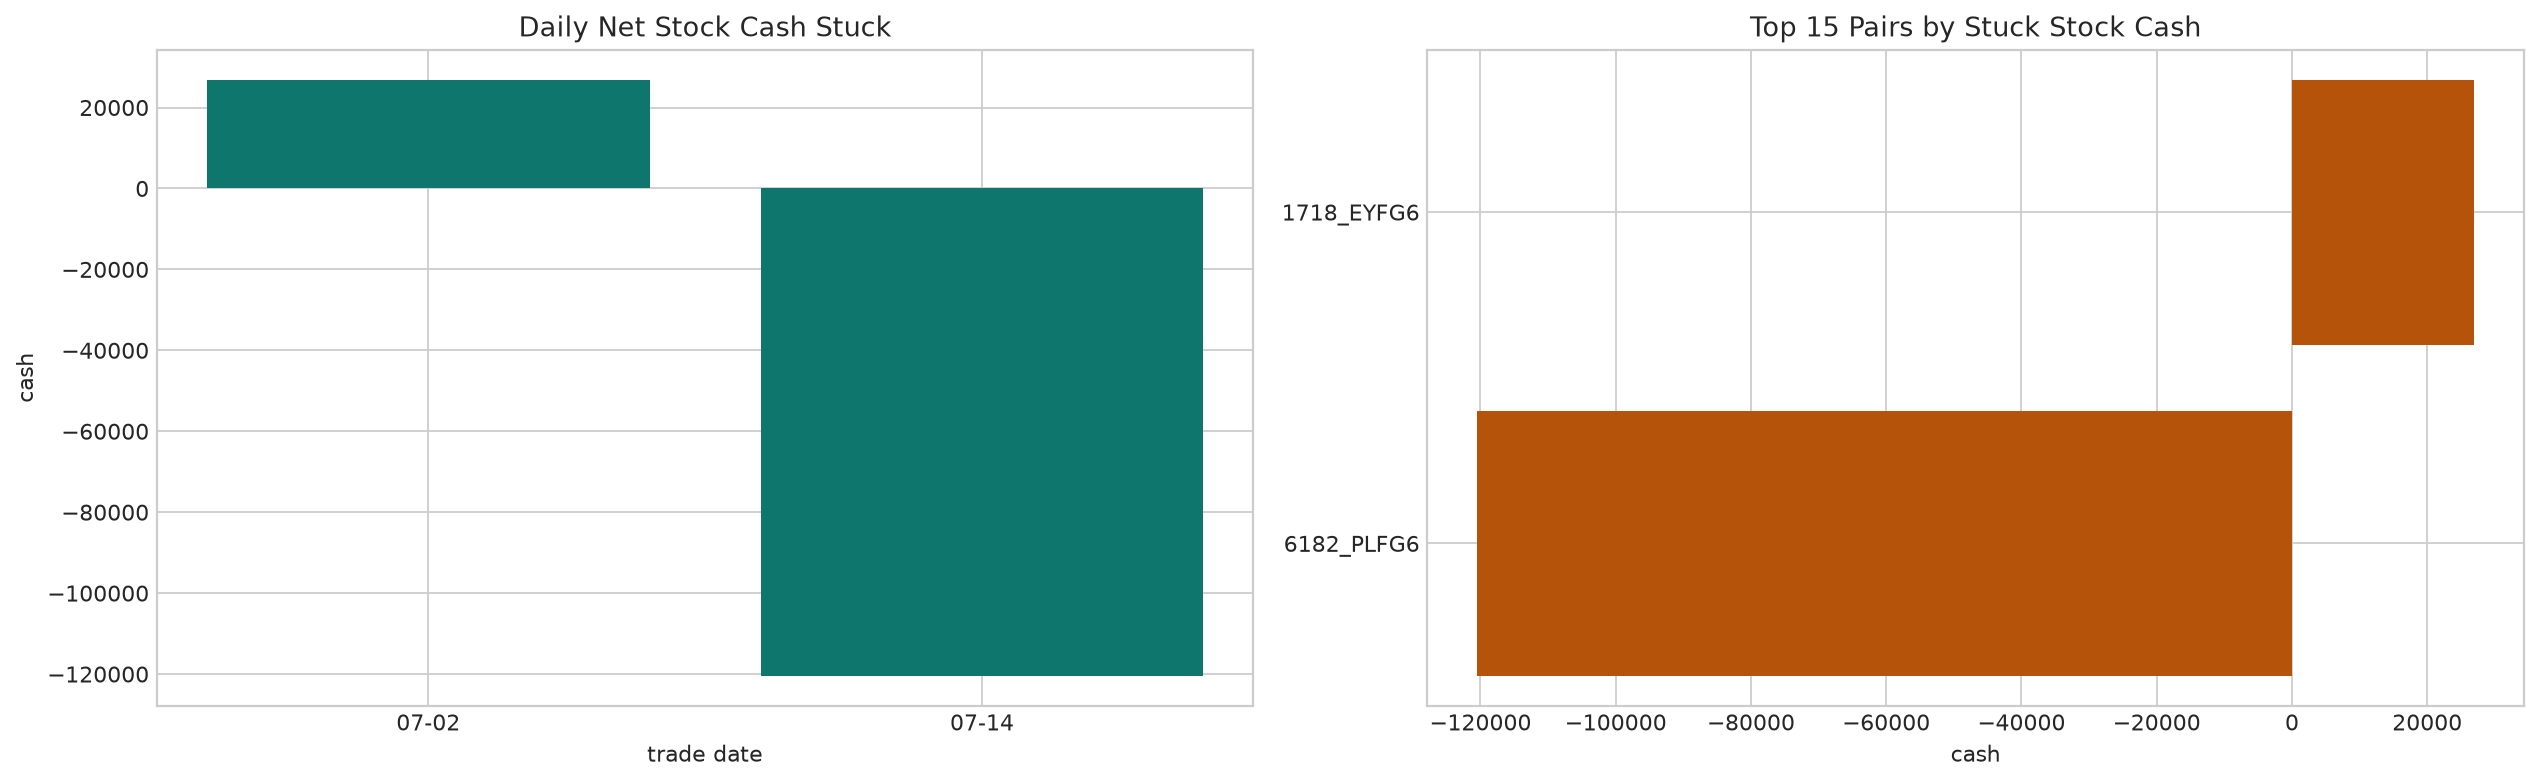

roi_including_open: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260701_20260731_latency_10ms/figures/roi_including_open.png


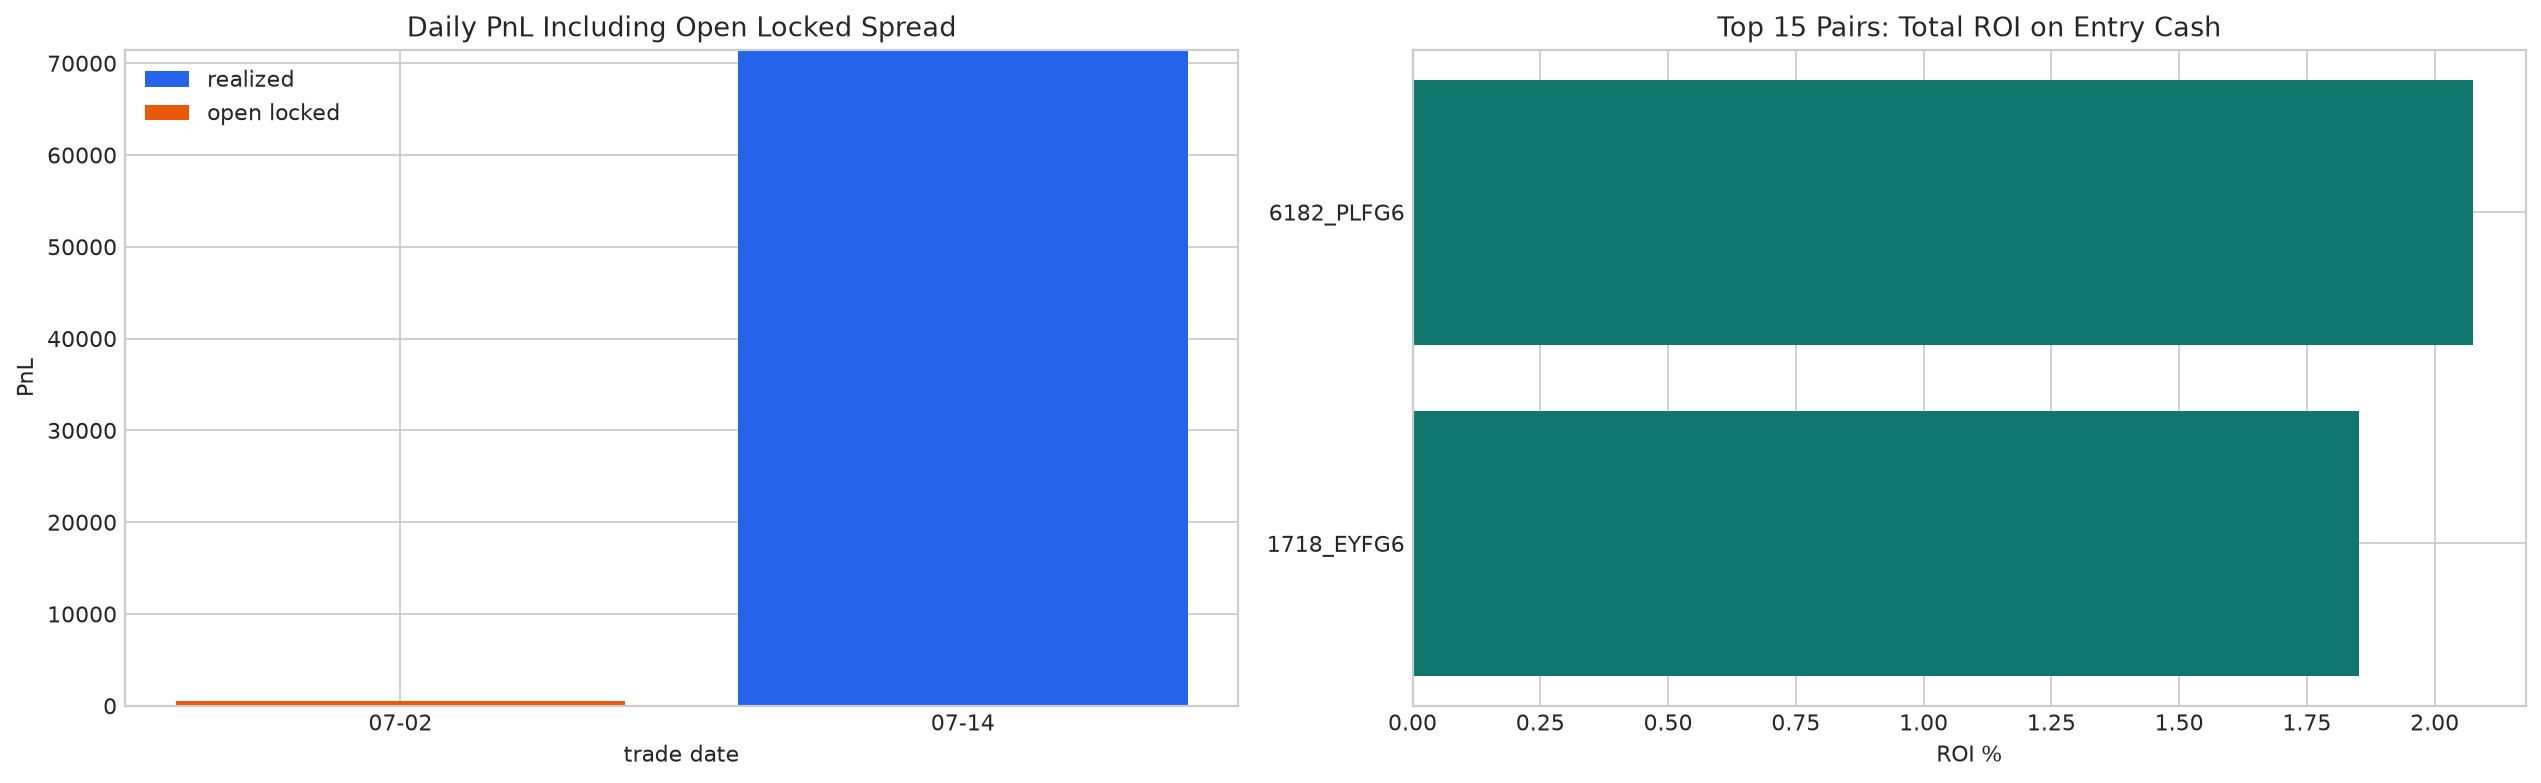

latency_timelines: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260701_20260731_latency_10ms/figures/latency_timelines.png


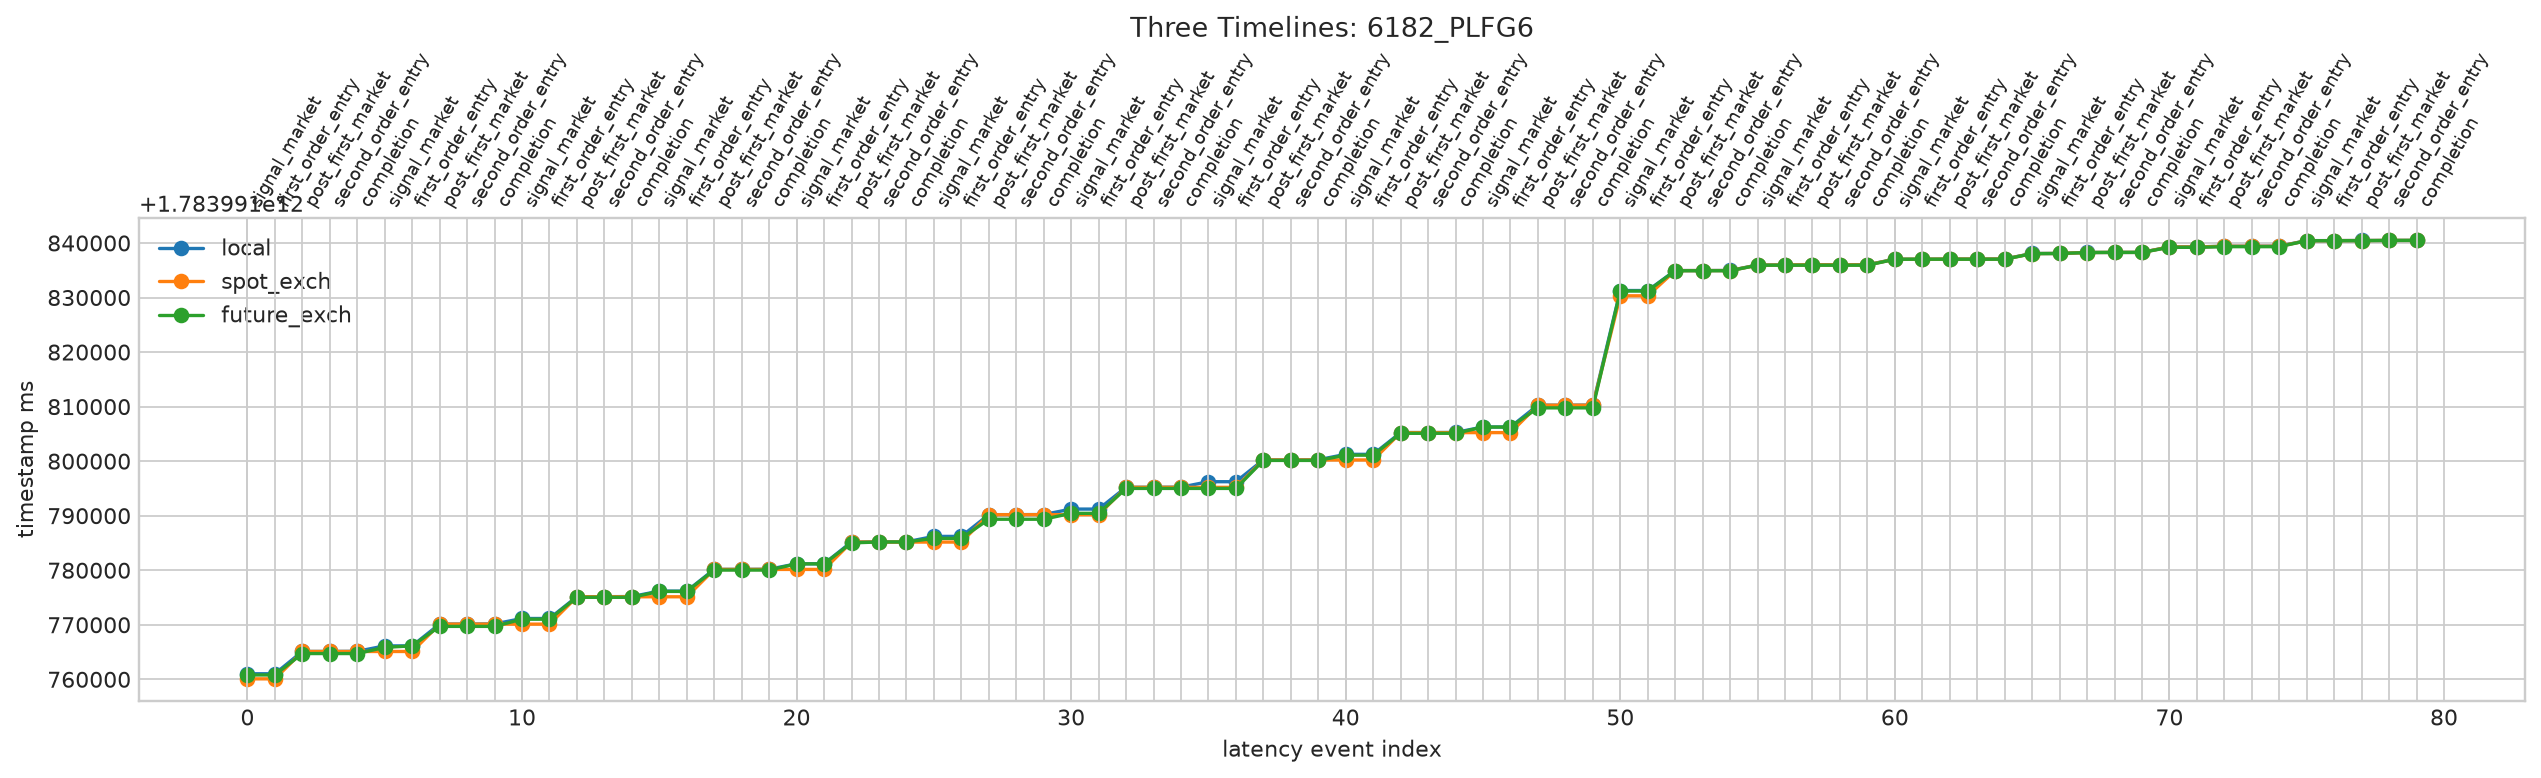

In [5]:
figure_paths = save_report_plots(artifacts, reports)
for name, path in figure_paths.items():
    print(f'{name}: {path}')
    display(Image(filename=str(path)))

## 5. Optional Drill-down

In [6]:
selected_pair = reports.selected_pair
entry_exit = artifacts.frame('entry_exit_all')
latency = artifacts.frame('latency')
if selected_pair is None:
    print('No pair is available for drill-down.')
else:
    if 'pair_name' in entry_exit.columns:
        display(entry_exit.loc[entry_exit['pair_name'].eq(selected_pair)].head(100))
    if 'pair_name' in latency.columns:
        display(latency.loc[latency['pair_name'].eq(selected_pair)].head(120))

,trade_date,run_key,time,pair_name,spot_symbol,future_symbol,entry_signal,spot_bid,spot_ask,spot_ask_size,...,first_side,first_requested_price,first_exec_price,first_exec_qty,second_leg,second_side,second_requested_price,second_exec_price,second_exec_qty,first_to_second_exch_ms
3578,2026-07-14,2026-07-14::6182_PLFG6,2026-07-14 09:16:01.023000+08:00,6182_PLFG6,6182,PLFG6,ENTER_LONG_SPOT_SHORT_FUTURE,172.0,172.5,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3579,2026-07-14,2026-07-14::6182_PLFG6,2026-07-14 09:16:05.133000+08:00,6182_PLFG6,6182,PLFG6,ENTER_LONG_SPOT_SHORT_FUTURE,172.0,172.5,NaN,...,sell,176.5,176.5,1.0,stock,buy,173.5,172.5,2.0,4090.000128
3580,2026-07-14,2026-07-14::6182_PLFG6,2026-07-14 09:16:06.133000+08:00,6182_PLFG6,6182,PLFG6,ENTER_LONG_SPOT_SHORT_FUTURE,172.0,172.5,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3581,2026-07-14,2026-07-14::6182_PLFG6,2026-07-14 09:16:10.153000+08:00,6182_PLFG6,6182,PLFG6,ENTER_LONG_SPOT_SHORT_FUTURE,171.5,172.0,NaN,...,sell,176.5,176.5,1.0,stock,buy,173.0,172.0,2.0,4000.000000
3582,2026-07-14,2026-07-14::6182_PLFG6,2026-07-14 09:16:11.153000+08:00,6182_PLFG6,6182,PLFG6,ENTER_LONG_SPOT_SHORT_FUTURE,171.5,172.0,78.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3645,2026-07-14,2026-07-14::6182_PLFG6,2026-07-14 09:17:23.603000+08:00,6182_PLFG6,6182,PLFG6,EXIT,179.5,180.0,220.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3646,2026-07-14,2026-07-14::6182_PLFG6,2026-07-14 09:17:24.603000+08:00,6182_PLFG6,6182,PLFG6,EXIT,179.5,180.0,215.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3647,2026-07-14,2026-07-14::6182_PLFG6,2026-07-14 09:17:24.673000+08:00,6182_PLFG6,6182,PLFG6,EXIT,179.5,180.0,NaN,...,buy,179.5,179.5,1.0,stock,sell,178.5,179.5,2.0,50.000128
3648,2026-07-14,2026-07-14::6182_PLFG6,2026-07-14 09:17:25.673000+08:00,6182_PLFG6,6182,PLFG6,EXIT,179.0,179.5,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,trade_date,run_key,timestamp,step,pair_name,spot_symbol,future_symbol,signal,status,failure_reason,...,spot_feed_latency_ns,future_exch_ts,future_feed_local_ts,future_feed_latency_ns,order_req_local_ts,order_exch_ts,order_resp_local_ts,order_entry_latency_ns,order_response_latency_ns,time
8943,2026-07-14,2026-07-14::6182_PLFG6,1783991761023000000,961,6182_PLFG6,6182,PLFG6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,None,...,10000000,1783991760801000000,1783991760811000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-07-14 09:16:01.023000+08:00
8944,2026-07-14,2026-07-14::6182_PLFG6,1783991761043000000,961,6182_PLFG6,6182,PLFG6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,None,...,10000000,1783991760801000000,1783991760811000000,10000000,1.783992e+18,1.783992e+18,1.783992e+18,10000000.0,10000000.0,2026-07-14 09:16:01.023000+08:00
8945,2026-07-14,2026-07-14::6182_PLFG6,1783991765113000000,961,6182_PLFG6,6182,PLFG6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,None,...,10000000,1783991764724000000,1783991764734000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-07-14 09:16:05.113000+08:00
8946,2026-07-14,2026-07-14::6182_PLFG6,1783991765133000000,961,6182_PLFG6,6182,PLFG6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,None,...,10000000,1783991764724000000,1783991764734000000,10000000,1.783992e+18,1.783992e+18,1.783992e+18,10000000.0,10000000.0,2026-07-14 09:16:05.113000+08:00
8947,2026-07-14,2026-07-14::6182_PLFG6,1783991765133000000,961,6182_PLFG6,6182,PLFG6,ENTER_LONG_SPOT_SHORT_FUTURE,FILLED,None,...,10000000,1783991764724000000,1783991764734000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-07-14 09:16:05.133000+08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9038,2026-07-14,2026-07-14::6182_PLFG6,1783991845673000000,1001,6182_PLFG6,6182,PLFG6,EXIT,SIGNAL,None,...,10000000,1783991845661000000,1783991845671000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-07-14 09:17:25.673000+08:00
9039,2026-07-14,2026-07-14::6182_PLFG6,1783991845693000000,1001,6182_PLFG6,6182,PLFG6,EXIT,FIRST_ORDER_RESPONSE,None,...,10000000,1783991845661000000,1783991845671000000,10000000,1.783992e+18,1.783992e+18,1.783992e+18,10000000.0,10000000.0,2026-07-14 09:17:25.673000+08:00
9040,2026-07-14,2026-07-14::6182_PLFG6,1783991845703000000,1001,6182_PLFG6,6182,PLFG6,EXIT,POST_FIRST_MARKET,None,...,10000000,1783991845661000000,1783991845671000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-07-14 09:17:25.703000+08:00
9041,2026-07-14,2026-07-14::6182_PLFG6,1783991845723000000,1001,6182_PLFG6,6182,PLFG6,EXIT,SECOND_ORDER_RESPONSE,None,...,10000000,1783991845700000000,1783991845710000000,10000000,1.783992e+18,1.783992e+18,1.783992e+18,10000000.0,10000000.0,2026-07-14 09:17:25.703000+08:00
